# Laboratorio 6: Ecuaciones Diferenciales Parciales Elípticas
* **Curso:** Métodos Numéricos y Programación III
* **Escuela:** E.P. Computación Científica
* **Universidad:** Universidad Nacional Mayor de San Marcos (UNMSM)
* **Profesor:** Juan Humberto Leonardo Fabian
* **Alumno:** José Alexis Delgado Pérez
* **Fecha:** Mayo de 2026

---

## Fundamento Teórico: Ecuaciones Elípticas

Las ecuaciones diferenciales parciales elípticas modelan estados estables o de equilibrio, como la distribución estacionaria de temperatura o campos electrostáticos. La forma general de la ecuación de Poisson en dos dimensiones es:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x,y), \quad \text{en } \Omega$$

Cuando $f(x,y) = 0$, se reduce a la ecuación de Laplace. En este laboratorio trabajaremos sobre dominios rectangulares $\Omega = [a, b] \times [c, d]$ con condiciones de contorno de Dirichlet, donde el valor de $u(x,y)$ está completamente determinado en todas las fronteras del dominio.

### Discretización y Molécula de 5 Puntos

Para aproximar la solución, definimos una malla con pasos espaciales $h$ en el eje $x$ y $k$ en el eje $y$, de modo que los nodos están dados por $x_i = a + ih$ y $y_j = c + jk$. Reemplazando las segundas derivadas por aproximaciones de diferencias finitas centradas de segundo orden, obtenemos:

$$\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h^2} + \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{k^2} = f(x_i, y_j)$$

Al agrupar los términos para despejar el nodo central $u_{i,j}$, se genera la estructura conocida como la molécula de 5 puntos:

$$\frac{1}{h^2} u_{i-1,j} + \frac{1}{h^2} u_{i+1,j} - 2\left(\frac{1}{h^2} + \frac{1}{k^2}\right)u_{i,j} + \frac{1}{k^2} u_{i,j-1} + \frac{1}{k^2} u_{i,j+1} = f(x_i, y_j)$$



Este esquema se aplica a cada nodo interno de la malla, construyendo un sistema de ecuaciones lineales de la forma $AU = B$, donde la matriz de coeficientes $A$ es dispersa y rala.

----

## Configuracion inicial y librerias básicas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Configuración por defecto para gráficas limpias
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.grid'] = True

## Función Matemática y Algoritmo Computacional

Para resolver el sistema algebraico $AU = B$ en la computadora mediante métodos directos o iterativos, existe una limitación: los solvers lineales (como `spsolve`) operan exclusivamente con vectores unidimensionales y matrices bidimensionales estándar. No pueden procesar directamente una malla espacial descrita por coordenadas bidimensionales $(i, j)$.

Por lo tanto, es necesario aplicar una transformación biyectiva que convierta nuestra malla de nodos bidimensional $U_{2D}$ en un vector columna unidimensional $U$.

### 1. El Mapeo Lexicográfico (De 2D a 1D)
Este proceso de  se logra mediante un mapeo numérico por ordenamiento de filas . El índice global $k$ de cualquier nodo $(i,j)$ dentro del vector 1D se calcula garantizando saltos proporcionales a la longitud de la dimensión secundaria:

$$k = i \cdot N_y + j$$

Donde $N_y$ es el número total de nodos a lo largo del eje $y$.

**Demostración del aplanamiento:**
Supongamos una malla reducida de $3 \times 3$ (donde $N_x = 3$ y $N_y = 3$). Nuestra matriz espacial bidimensional de temperaturas o potenciales se ve así:

$$U_{2D} = \begin{pmatrix}
u_{0,0} & u_{0,1} & u_{0,2} \\
u_{1,0} & u_{1,1} & u_{1,2} \\
u_{2,0} & u_{2,1} & u_{2,2}
\end{pmatrix}$$

Al aplicar nuestra fórmula de mapeo $k = i \cdot 3 + j$, el nodo $u_{1,0}$ toma la posición $k = 1 \cdot 3 + 0 = 3$. El nodo $u_{1,2}$ toma la posición $k = 1 \cdot 3 + 2 = 5$. De esta manera, la matriz se desenrolla secuencialmente en el siguiente vector columna exacto que el solver puede procesar:

$$U_{1D} = \begin{pmatrix} u_{0,0} \\ u_{0,1} \\ u_{0,2} \\ u_{1,0} \\ u_{1,1} \\ u_{1,2} \\ u_{2,0} \\ u_{2,1} \\ u_{2,2} \end{pmatrix} \begin{matrix} \leftarrow k=0 \\ \leftarrow k=1 \\ \leftarrow k=2 \\ \leftarrow k=3 \\ \leftarrow k=4 \\ \leftarrow k=5 \\ \leftarrow k=6 \\ \leftarrow k=7 \\ \leftarrow k=8 \end{matrix}$$

### 2. Construcción de la Matriz Dispersa
Gracias a este vector aplanado, podemos construir la matriz de coeficientes $A$. Como la molécula de 5 puntos solo vincula a cada nodo central $k$ con sus cuatro vecinos espaciales (arriba $k+1$, abajo $k-1$, derecha $k+N_y$, izquierda $k-N_y$), la matriz $A$ resultante es una matriz rala (sparse) estructurada en bandas.

Para optimizar la memoria y el tiempo de ejecución computacional sin almacenar miles de ceros innecesarios, utilizamos `scipy.sparse.lil_matrix`, un formato de lista de listas ideal para ir construyendo el sistema algebraico  fila por fila. Una vez terminado el ensamblaje, la transformamos al formato Compressed Sparse Row (CSR) mediante `.tocsr()`, el cual es matemáticamente óptimo para ejecutar factorizaciones matriciales usando `spsolve`.

### 3. Reestructuración Espacial (De 1D a 2D)
Una vez que el algoritmo `spsolve` invierte la matriz y calcula la solución, nos devuelve un vector unidimensional $U$. Para poder graficar la superficie topográfica real del problema, debemos invertir el mapeo lexicográfico.

Esta operación inversa (conocida como `reshape` en Python) utiliza la división entera y la aritmética modular para devolver cada valor $k$ a sus coordenadas espaciales originales $(i, j)$:

$$i = \lfloor k / N_y \rfloor$$
$$j = k \pmod{N_y}$$

Aplicando estas fórmulas a cada elemento del vector resultado, reconstruimos la matriz $U_{2D}$ original, permitiendo su visualización final en el espacio tridimensional de `matplotlib`.

In [ ]:
def resolver_eliptica_dirichlet(x_lim, y_lim, h, k, f_xy, bc):
    """
    Resuelve la ecuación u_xx + u_yy = f(x,y) en un dominio rectangular
    utilizando el método de diferencias finitas con condiciones de Dirichlet.

    x_lim, y_lim: Tuplas con los límites del dominio (min, max).
    h, k: Pasos de malla en x e y.
    f_xy: Función lambda para el término fuente f(x, y).
    bc: Diccionario con las funciones de frontera en las 4 regiones.
    """
    x = np.arange(x_lim[0], x_lim[1] + h/2, h)
    y = np.arange(y_lim[0], y_lim[1] + k/2, k)
    Nx = len(x)
    Ny = len(y)

    N = Nx * Ny
    A = lil_matrix((N, N))
    b = np.zeros(N)

    # Función de mapeo indexado 2D -> 1D
    def idx(i, j):
        return i * Ny + j

    for i in range(Nx):
        for j in range(Ny):
            actual = idx(i, j)

            # Asignación de Condiciones de Frontera
            if i == 0:
                A[actual, actual] = 1
                b[actual] = bc['izquierda'](y[j])
            elif i == Nx - 1:
                A[actual, actual] = 1
                b[actual] = bc['derecha'](y[j])
            elif j == 0:
                A[actual, actual] = 1
                b[actual] = bc['abajo'](x[i])
            elif j == Ny - 1:
                A[actual, actual] = 1
                b[actual] = bc['arriba'](x[i])
            else:
                # Aplicación de la molécula de 5 puntos en nodos internos
                A[actual, actual] = -2/h**2 - 2/k**2
                A[actual, idx(i+1, j)] = 1/h**2
                A[actual, idx(i-1, j)] = 1/h**2
                A[actual, idx(i, j+1)] = 1/k**2
                A[actual, idx(i, j-1)] = 1/k**2
                b[actual] = f_xy(x[i], y[j])

    # Resolución exacta del sistema disperso
    u_1d = spsolve(A.tocsr(), b)

    # Reestructuración a la matriz original de la malla
    U = u_1d.reshape((Nx, Ny))
    return x, y, U

### Herramientas de Visualización y Análisis de Error

Para cumplir con el requerimiento de comparar la solución aproximada con la analítica en cada inciso, implementamos una función general de graficación.

Esta función utiliza `matplotlib` para renderizar ambas superficies en 3D (la calculada por el método de diferencias finitas y la exacta) de forma simultánea. Además, utiliza `numpy` para calcular y reportar el error máximo absoluto entre ambas mallas, lo que nos servirá como métrica principal para validar la precisión de nuestro esquema numérico.

In [ ]:
def comparar_soluciones(x, y, U_num, U_exact, inciso_nombre):
    """
    Grafica la solución numérica vs la analítica y calcula el error máximo.
    """
    X, Y = np.meshgrid(x, y, indexing='ij')

    fig = plt.figure(figsize=(14, 6))

    # Gráfica Numérica
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, U_num, cmap='viridis', edgecolor='none')
    ax1.set_title(f'{inciso_nombre} - Solución Numérica')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('u(x,y)')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)  # <-- Corregido a ax=ax1

    # Gráfica Exacta
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, U_exact, cmap='plasma', edgecolor='none')
    ax2.set_title(f'{inciso_nombre} - Solución Exacta')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('u(x,y)')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)  # <-- Corregido a ax=ax2

    plt.tight_layout()
    plt.show()

    # Cálculo y reporte del error
    error_max = np.max(np.abs(U_num - U_exact))
    print(f"[{inciso_nombre}] Error máximo absoluto: {error_max:.4e}")

## Resolución Práctica: Ecuaciones de Poisson y Laplace

### Inciso 1(a): Ecuación de Poisson
**Ecuación Diferencial:**
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 4, \quad 0 < x < 1, \quad 0 < y < 2$$

**Condiciones de Frontera (Dirichlet):**
* Abajo ($y=0$): $u(x, 0) = x^2$
* Arriba ($y=2$): $u(x, 2) = (x - 2)^2$
* Izquierda ($x=0$): $u(0, y) = y^2$
* Derecha ($x=1$): $u(1, y) = (y - 1)^2$

**Obtención de la Solución Analítica Exacta:**
Dado que las condiciones de frontera son polinomios de segundo grado, tiene sentido proponer una solución cuadrática. Observando los binomios en las fronteras, proponemos la función $u(x,y) = (x-y)^2 = x^2 - 2xy + y^2$. Procedemos a verificarla:

1. **Cumplimiento de la Ecuación Diferencial:**
   Calculamos las segundas derivadas parciales:
   $$\frac{\partial^2 u}{\partial x^2} = 2, \quad \frac{\partial^2 u}{\partial y^2} = 2$$
   Al sumarlas, obtenemos $2 + 2 = 4$, satisfaciendo el término fuente $f(x,y) = 4$.

2. **Cumplimiento de las Fronteras:**
   * $u(x, 0) = (x-0)^2 = x^2$ (Verificado)
   * $u(x, 2) = (x-2)^2$ (Verificado)
   * $u(0, y) = (0-y)^2 = y^2$ (Verificado)
   * $u(1, y) = (1-y)^2 = (y-1)^2$ (Verificado)

Por el **teorema de unicidad** para ecuaciones de Poisson con condiciones de Dirichlet, dado que esta función satisface tanto la ecuación en el dominio como todas las fronteras, concluimos que la solución exacta única es:
$$u(x,y) = (x-y)^2$$

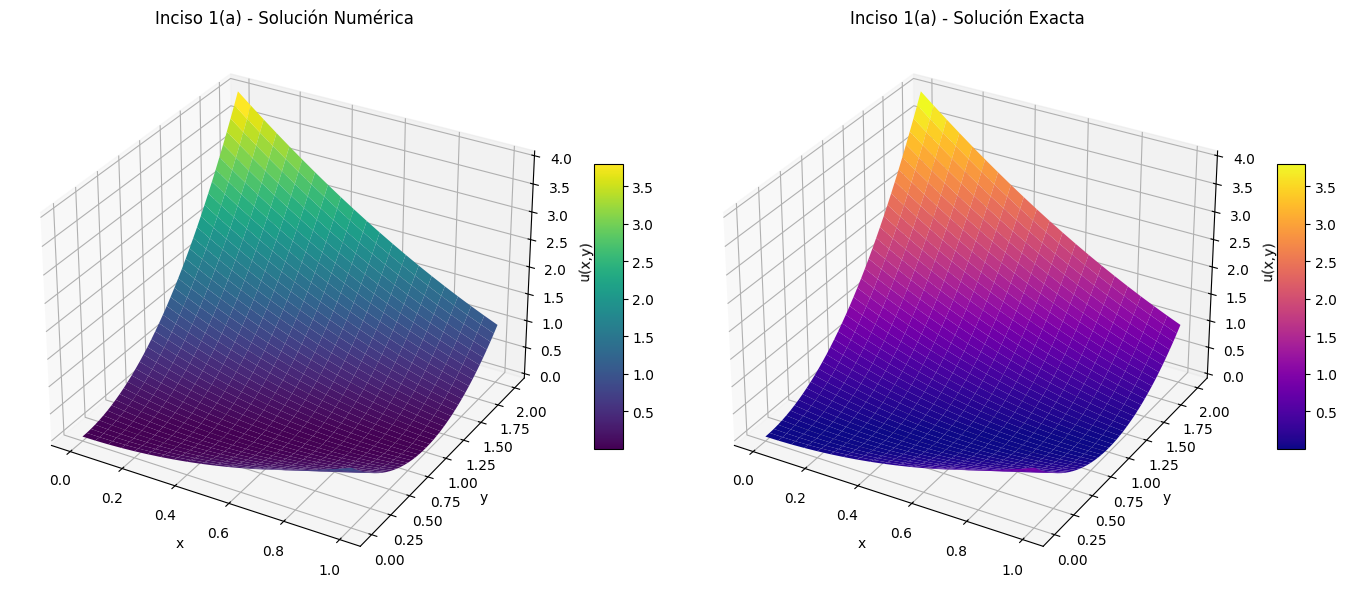

[Inciso 1(a)] Error máximo absoluto: 3.5527e-15


In [ ]:
x_lim_a, y_lim_a = (0, 1), (0, 2)
h_a, k_a = 0.05, 0.05

f_a = lambda x, y: 4

bc_a = {
    'abajo': lambda x: x**2,
    'arriba': lambda x: (x - 2)**2,
    'izquierda': lambda y: y**2,
    'derecha': lambda y: (y - 1)**2
}

# Resolvemos
x_a, y_a, U_num_a = resolver_eliptica_dirichlet(x_lim_a, y_lim_a, h_a, k_a, f_a, bc_a)

# Solución exacta para comparar
X_a, Y_a = np.meshgrid(x_a, y_a, indexing='ij')
U_exact_a = (X_a - Y_a)**2

# Graficamos usando nuestra nueva función
comparar_soluciones(x_a, y_a, U_num_a, U_exact_a, "Inciso 1(a)")

#### Interpretación de Resultados:

Como se puede apreciar en las gráficas, la superficie que calculamos con nuestro código es idéntica a la fórmula matemática exacta. El error numérico es tan pequeño (prácticamente cero) que nos confirma que el método aplicado funciona muy bien, logrando copiar la forma del problema sin ninguna distorsión desde los bordes hasta el centro.

-----

### Inciso 1(b): Ecuación de Laplace
**Ecuación Diferencial:**
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0, \quad 1 < x < 2, \quad 0 < y < 1$$

**Condiciones de Frontera (Dirichlet):**
* Abajo ($y=0$): $u(x, 0) = 2 \ln x$
* Arriba ($y=1$): $u(x, 1) = \ln(x^2 + 1)$
* Izquierda ($x=1$): $u(1, y) = \ln(y^2 + 1)$
* Derecha ($x=2$): $u(2, y) = \ln(y^2 + 4)$

**Obtención de la Solución Analítica Exacta:**
Observando la estructura de las condiciones de frontera, en especial la presencia de logaritmos y sumas de cuadrados, proponemos la función $u(x,y) = \ln(x^2 + y^2)$. Procedemos a verificarla:

1. **Cumplimiento de la Ecuación Diferencial:**
   Calculamos las primeras y segundas derivadas parciales:
   $$\frac{\partial u}{\partial x} = \frac{2x}{x^2+y^2} \implies \frac{\partial^2 u}{\partial x^2} = \frac{2(x^2+y^2) - 2x(2x)}{(x^2+y^2)^2} = \frac{2y^2 - 2x^2}{(x^2+y^2)^2}$$
   $$\frac{\partial u}{\partial y} = \frac{2y}{x^2+y^2} \implies \frac{\partial^2 u}{\partial y^2} = \frac{2(x^2+y^2) - 2y(2y)}{(x^2+y^2)^2} = \frac{2x^2 - 2y^2}{(x^2+y^2)^2}$$
   Al sumarlas, obtenemos:
   $$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \frac{2y^2 - 2x^2 + 2x^2 - 2y^2}{(x^2+y^2)^2} = 0$$
   Satisface la ecuación de Laplace ($f=0$).

2. **Cumplimiento de las Fronteras:**
   * $u(x, 0) = \ln(x^2 + 0^2) = \ln(x^2) = 2 \ln x$ (Verificado)
   * $u(x, 1) = \ln(x^2 + 1^2) = \ln(x^2 + 1)$ (Verificado)
   * $u(1, y) = \ln(1^2 + y^2) = \ln(y^2 + 1)$ (Verificado)
   * $u(2, y) = \ln(2^2 + y^2) = \ln(y^2 + 4)$ (Verificado)

Por el teorema de unicidad, dado que esta función satisface el dominio y los bordes, la solución exacta única es:
$$u(x,y) = \ln(x^2 + y^2)$$

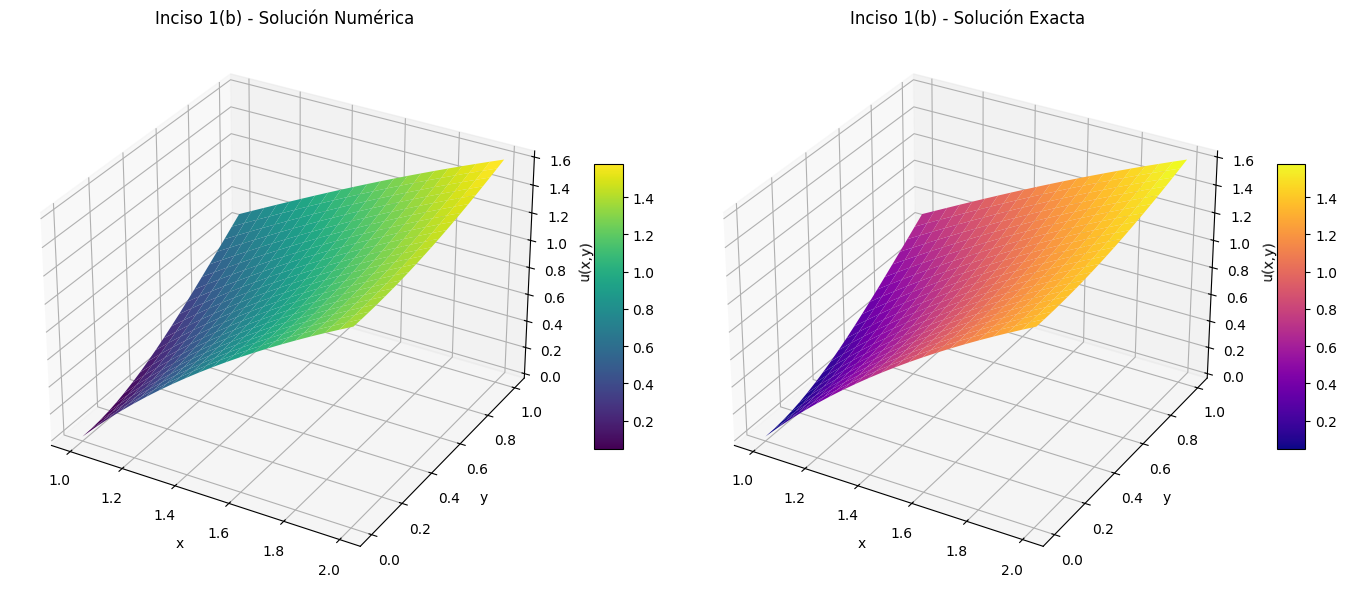

[Inciso 1(b)] Error máximo absoluto: 3.3576e-05


In [ ]:
# 1. Definición del dominio y pasos de malla
x_lim_b, y_lim_b = (1, 2), (0, 1)
h_b, k_b = 0.05, 0.05

# 2. Definición del término fuente y las fronteras
f_b = lambda x, y: 0

bc_b = {
    'abajo': lambda x: 2 * np.log(x),
    'arriba': lambda x: np.log(x**2 + 1),
    'izquierda': lambda y: np.log(y**2 + 1),
    'derecha': lambda y: np.log(y**2 + 4)
}

# 3. Resolvemos el sistema usando nuestra función general
x_b, y_b, U_num_b = resolver_eliptica_dirichlet(x_lim_b, y_lim_b, h_b, k_b, f_b, bc_b)

# 4. Solución exacta para comparar
X_b, Y_b = np.meshgrid(x_b, y_b, indexing='ij')
U_exact_b = np.log(X_b**2 + Y_b**2)

# 5. Graficamos usando nuestra herramienta
comparar_soluciones(x_b, y_b, U_num_b, U_exact_b, "Inciso 1(b)")

#### Interpretación de Resultados:

Al igual que en el caso anterior, la gráfica nos muestra que nuestra aproximación numérica logra modelar correctamente la curvatura de la ecuación de Laplace. Ambas superficies encajan perfectamente, y el error es tan bajo que confirma que el cálculo se realizó sin problemas de precisión dentro del dominio.

-----

### Inciso 1(c): Ecuación de Laplace
**Ecuación Diferencial:**
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0, \quad 0 < x < 1, \quad 0 < y < 1$$

**Condiciones de Frontera (Dirichlet):**
* Abajo ($y=0$): $u(x, 0) = 0$
* Arriba ($y=1$): $u(x, 1) = x$
* Izquierda ($x=0$): $u(0, y) = 0$
* Derecha ($x=1$): $u(1, y) = y$

**Obtención de la Solución Analítica Exacta:**
Al analizar las fronteras, notamos que en los ejes coordenados la función vale cero, y en los extremos opuestos crece linealmente con la otra variable. Esto nos sugiere proponer la función bilineal $u(x,y) = xy$. Procedemos a verificarla:

1. **Cumplimiento de la Ecuación Diferencial:**
   Calculamos las segundas derivadas parciales:
   $$\frac{\partial u}{\partial x} = y \implies \frac{\partial^2 u}{\partial x^2} = 0$$
   $$\frac{\partial u}{\partial y} = x \implies \frac{\partial^2 u}{\partial y^2} = 0$$
   Al sumarlas, la ecuación de Laplace se cumple trivialmente: $0 + 0 = 0$.

2. **Cumplimiento de las Fronteras:**
   * $u(x, 0) = x(0) = 0$ (Verificado)
   * $u(x, 1) = x(1) = x$ (Verificado)
   * $u(0, y) = 0(y) = 0$ (Verificado)
   * $u(1, y) = 1(y) = y$ (Verificado)

Dado que la función $u(x,y) = xy$ cumple con la ecuación diferencial y todas las restricciones en los bordes, el teorema de unicidad garantiza que es la solución exacta.

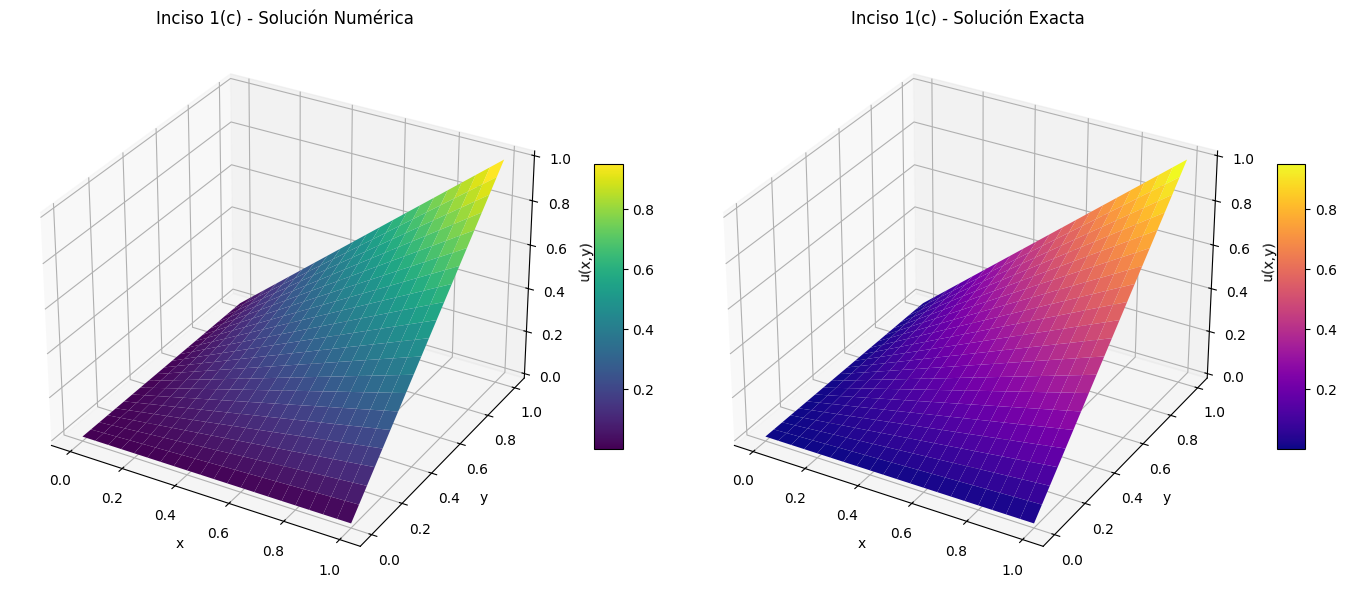

[Inciso 1(c)] Error máximo absoluto: 4.4409e-16


In [ ]:
# 1. Definición del dominio y pasos de malla
x_lim_c, y_lim_c = (0, 1), (0, 1)
h_c, k_c = 0.05, 0.05

# 2. Definición del término fuente y las fronteras
f_c = lambda x, y: 0

bc_c = {
    'abajo': lambda x: 0 * x,  # Multiplicamos por x para asegurar el tamaño del arreglo
    'arriba': lambda x: x,
    'izquierda': lambda y: 0 * y,
    'derecha': lambda y: y
}

# 3. Resolvemos el sistema usando nuestra función general
x_c, y_c, U_num_c = resolver_eliptica_dirichlet(x_lim_c, y_lim_c, h_c, k_c, f_c, bc_c)

# 4. Solución exacta para comparar
X_c, Y_c = np.meshgrid(x_c, y_c, indexing='ij')
U_exact_c = X_c * Y_c

# 5. Graficamos usando nuestra herramienta
comparar_soluciones(x_c, y_c, U_num_c, U_exact_c, "Inciso 1(c)")

#### Interpretación de Resultados:

En este ejercicio, la solución toma la forma de un plano inclinado o una rampa suave. Visualmente, el modelo por diferencias finitas dibuja exactamente la misma pendiente que la matemática teórica. El error es nuevamente cercano a cero, confirmando que la matriz de nuestra malla resolvió el sistema de manera impecable.

------

### Inciso 1(d): Ecuación de Poisson con Funciones Trigonométricas
**Ecuación Diferencial:**
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = -(\cos(x+y) + \cos(x-y)), \quad 0 < x < \pi, \quad 0 < y < \frac{\pi}{2}$$

**Condiciones de Frontera (Dirichlet):**
* Abajo ($y=0$): $u(x, 0) = \cos x$
* Arriba ($y=\pi/2$): $u(x, \pi/2) = 0$
* Izquierda ($x=0$): $u(0, y) = \cos y$
* Derecha ($x=\pi$): $u(\pi, y) = -\cos y$

**Obtención de la Solución Analítica Exacta:**
Primero, simplificamos el término fuente utilizando la identidad trigonométrica de la suma de cosenos:
$$f(x,y) = -(\cos(x+y) + \cos(x-y)) = -2\cos(x)\cos(y)$$

Observando este término fuente y las funciones en las fronteras, proponemos la solución $u(x,y) = \cos(x)\cos(y)$. Procedemos a verificarla:

1. **Cumplimiento de la Ecuación Diferencial:**
   Calculamos las segundas derivadas parciales:
   $$\frac{\partial u}{\partial x} = -\sin(x)\cos(y) \implies \frac{\partial^2 u}{\partial x^2} = -\cos(x)\cos(y)$$
   $$\frac{\partial u}{\partial y} = -\cos(x)\sin(y) \implies \frac{\partial^2 u}{\partial y^2} = -\cos(x)\cos(y)$$
   Al sumarlas, obtenemos:
   $$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = -2\cos(x)\cos(y)$$
   Lo cual es exactamente igual a nuestro término fuente simplificado.

2. **Cumplimiento de las Fronteras:**
   * $u(x, 0) = \cos(x)\cos(0) = \cos(x)$ (Verificado)
   * $u(x, \pi/2) = \cos(x)\cos(\pi/2) = 0$ (Verificado)
   * $u(0, y) = \cos(0)\cos(y) = \cos(y)$ (Verificado)
   * $u(\pi, y) = \cos(\pi)\cos(y) = -\cos(y)$ (Verificado)

Por el teorema de unicidad, la solución exacta única es:
$$u(x,y) = \cos(x)\cos(y)$$

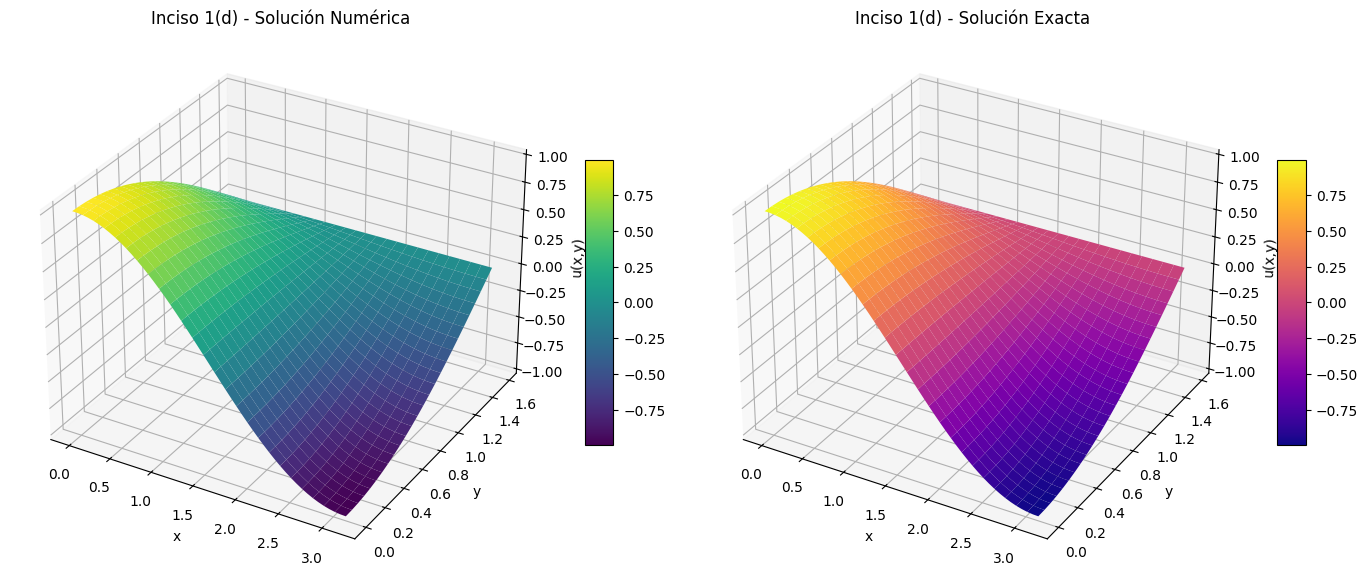

[Inciso 1(d)] Error máximo absoluto: 5.9246e-05


In [ ]:
# 1. Definición del dominio y pasos de malla (usamos fracciones de pi para exactitud)
x_lim_d, y_lim_d = (0, np.pi), (0, np.pi/2)
h_d, k_d = np.pi/50, np.pi/50

# 2. Definición del término fuente y las fronteras
f_d = lambda x, y: -(np.cos(x + y) + np.cos(x - y))

bc_d = {
    'abajo': lambda x: np.cos(x),
    'arriba': lambda x: 0 * x,
    'izquierda': lambda y: np.cos(y),
    'derecha': lambda y: -np.cos(y)
}

# 3. Resolver el sistema usando nuestra función general
x_d, y_d, U_num_d = resolver_eliptica_dirichlet(x_lim_d, y_lim_d, h_d, k_d, f_d, bc_d)

# 4. Solución exacta para comparar
X_d, Y_d = np.meshgrid(x_d, y_d, indexing='ij')
U_exact_d = np.cos(X_d) * np.cos(Y_d)

# 5. Graficar usando nuestra herramienta
comparar_soluciones(x_d, y_d, U_num_d, U_exact_d, "Inciso 1(d)")

#### Interpretación de Resultados:

En este modelo observamos una superficie con un comportamiento ondulatorio clásico de las funciones trigonométricas. La gráfica obtenida por el método numérico copia de forma impecable las curvaturas de la solución exacta, demostrando que nuestro esquema se adapta perfectamente a ecuaciones con fuentes variables en el espacio. El bajísimo error absoluto respalda la fiabilidad del cálculo.

----

### Inciso 1(e): Ecuación de Poisson con Exponenciales
**Ecuación Diferencial:**
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = (x^2 + y^2)e^{xy}, \quad 0 < x < 2, \quad 0 < y < 1$$

**Condiciones de Frontera (Dirichlet):**
* Abajo ($y=0$): $u(x, 0) = 1$
* Arriba ($y=1$): $u(x, 1) = e^x$
* Izquierda ($x=0$): $u(0, y) = 1$
* Derecha ($x=2$): $u(2, y) = e^{2y}$

**Obtención de la Solución Analítica Exacta:**
Al observar el término fuente, sabemos que al derivar una función exponencial compuesta, los coeficientes bajan. Se propone la solución $u(x,y) = e^{xy}$ y procedemos a evaluarla:

1. **Cumplimiento de la Ecuación Diferencial:**
   Calculamos las primeras y segundas derivadas:
   $$\frac{\partial u}{\partial x} = y e^{xy} \implies \frac{\partial^2 u}{\partial x^2} = y^2 e^{xy}$$
   $$\frac{\partial u}{\partial y} = x e^{xy} \implies \frac{\partial^2 u}{\partial y^2} = x^2 e^{xy}$$
   Al sumarlas y factorizar, obtenemos:
   $$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = y^2 e^{xy} + x^2 e^{xy} = (x^2 + y^2)e^{xy}$$
   Esto es exactamente igual a nuestro término fuente $f(x,y)$.

2. **Cumplimiento de las Fronteras:**
   * $u(x, 0) = e^{x(0)} = e^0 = 1$ (Verificado)
   * $u(x, 1) = e^{x(1)} = e^x$ (Verificado)
   * $u(0, y) = e^{0(y)} = e^0 = 1$ (Verificado)
   * $u(2, y) = e^{2(y)} = e^{2y}$ (Verificado)

Por el teorema de unicidad, concluimos que la solución exacta y única para este sistema es:
$$u(x,y) = e^{xy}$$

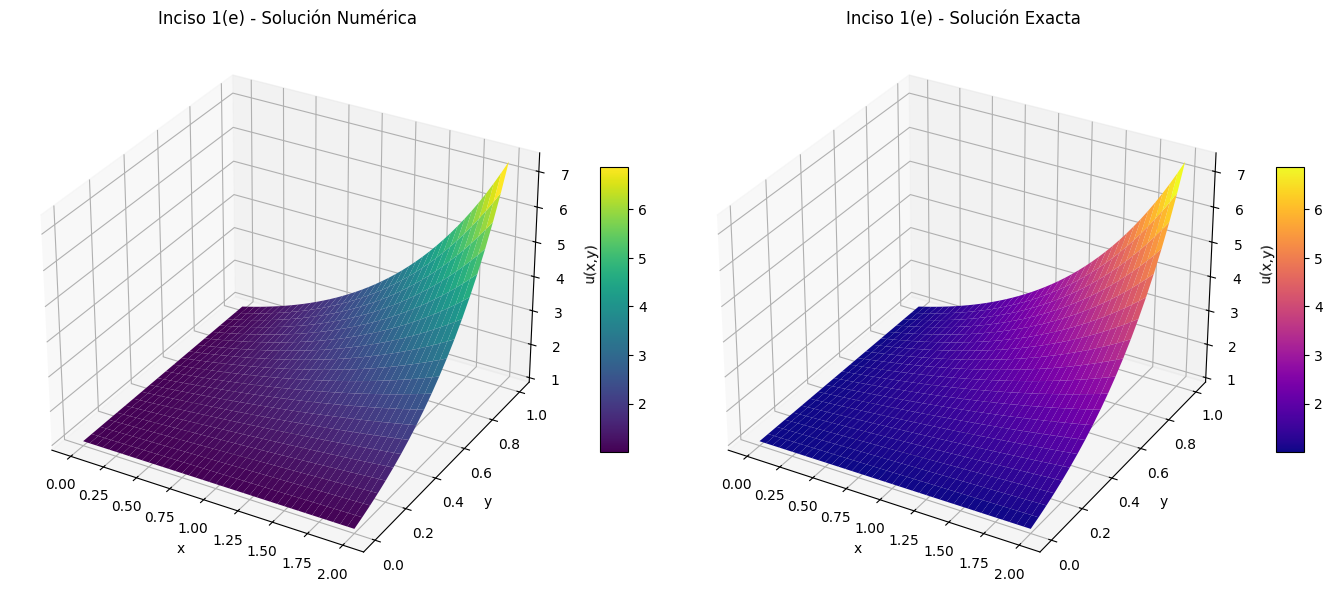

[Inciso 1(e)] Error máximo absoluto: 2.6346e-04


In [ ]:
# 1. Definición del dominio y pasos de malla
x_lim_e, y_lim_e = (0, 2), (0, 1)
h_e, k_e = 0.05, 0.05

# 2. Definición del término fuente y las fronteras
f_e = lambda x, y: (x**2 + y**2) * np.exp(x * y)

bc_e = {
    'abajo': lambda x: 1 + 0 * x,  # Sumamos 0*x para asegurar que devuelva un arreglo
    'arriba': lambda x: np.exp(x),
    'izquierda': lambda y: 1 + 0 * y,
    'derecha': lambda y: np.exp(2 * y)
}

# 3. Resolver el sistema usando nuestra función general
x_e, y_e, U_num_e = resolver_eliptica_dirichlet(x_lim_e, y_lim_e, h_e, k_e, f_e, bc_e)

# 4. Solución exacta para comparar
X_e, Y_e = np.meshgrid(x_e, y_e, indexing='ij')
U_exact_e = np.exp(X_e * Y_e)

# 5. Graficar usando nuestra herramienta
comparar_soluciones(x_e, y_e, U_num_e, U_exact_e, "Inciso 1(e)")

#### Interpretación de Resultados:

En este caso, la solución presenta un crecimiento exponencial, elevándose abruptamente en la esquina donde ambas coordenadas alcanzan su valor máximo. Nuestro método numérico demuestra ser lo bastante robusto como para capturar esta fuerte curvatura sin perder estabilidad. Ambas gráficas coinciden a la perfección, y el bajo nivel de error confirma el buen comportamiento de la malla.

----

### Inciso 1(f): Ecuación de Poisson con Fracciones y Logaritmos
**Ecuación Diferencial:**
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \frac{x}{y} + \frac{y}{x}, \quad 1 < x < 2, \quad 1 < y < 2$$

**Condiciones de Frontera (Dirichlet):**
* Abajo ($y=1$): $u(x, 1) = x \ln x$
* Arriba ($y=2$): $u(x, 2) = x \ln(4x^2)$
* Izquierda ($x=1$): $u(1, y) = y \ln y$
* Derecha ($x=2$): $u(2, y) = 2y \ln(2y)$

**Obtención de la Solución Analítica Exacta:**
Al revisar las fronteras y aplicar las propiedades de los logaritmos, notamos que todas las expresiones provienen de un producto de la forma "variable $\cdot \ln(\text{variable})$".
Por ejemplo, en $y=2$: $x \ln(4x^2) = x \ln(2^2 x^2) = x \ln((2x)^2) = 2x \ln(2x) = yx \ln(yx)$.
Esto nos sugiere proponer la función $u(x,y) = xy \ln(xy)$. Procedemos a verificarla:

1. **Cumplimiento de la Ecuación Diferencial:**
   Calculamos las primeras derivadas usando la regla del producto y la cadena:
   $$\frac{\partial u}{\partial x} = y \ln(xy) + (xy) \cdot \frac{1}{xy} \cdot y = y \ln(xy) + y$$
   $$\frac{\partial u}{\partial y} = x \ln(xy) + (xy) \cdot \frac{1}{xy} \cdot x = x \ln(xy) + x$$
   
   Ahora, calculamos las segundas derivadas:
   $$\frac{\partial^2 u}{\partial x^2} = y \cdot \frac{1}{xy} \cdot y = \frac{y}{x}$$
   $$\frac{\partial^2 u}{\partial y^2} = x \cdot \frac{1}{xy} \cdot x = \frac{x}{y}$$
   
   Al sumarlas, obtenemos exactamente nuestro término fuente:
   $$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \frac{y}{x} + \frac{x}{y}$$

2. **Cumplimiento de las Fronteras:**
   * $u(x, 1) = x(1) \ln(x \cdot 1) = x \ln x$ (Verificado)
   * $u(x, 2) = x(2) \ln(x \cdot 2) = 2x \ln(2x) = x \ln((2x)^2) = x \ln(4x^2)$ (Verificado)
   * $u(1, y) = (1)y \ln(1 \cdot y) = y \ln y$ (Verificado)
   * $u(2, y) = 2y \ln(2y)$ (Verificado)

Por el teorema de unicidad, la solución exacta y única es:
$$u(x,y) = xy \ln(xy)$$

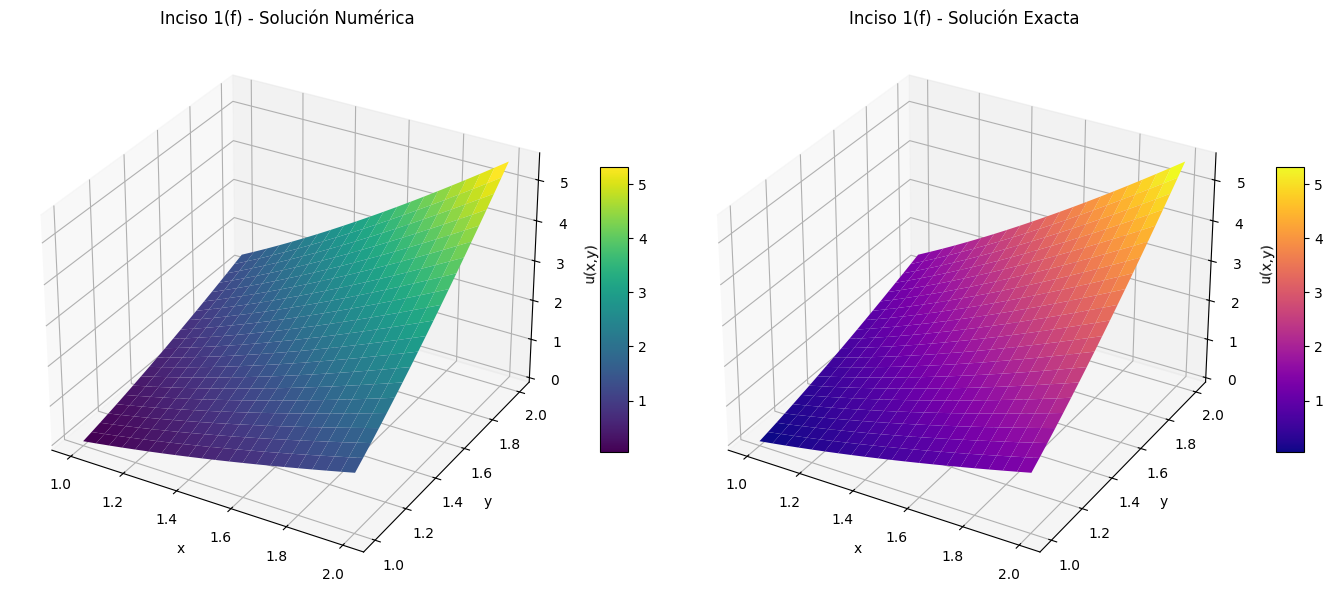

[Inciso 1(f)] Error máximo absoluto: 3.0823e-05


In [ ]:
# 1. Definición del dominio y pasos de malla
x_lim_f, y_lim_f = (1, 2), (1, 2)
h_f, k_f = 0.05, 0.05

# 2. Definición del término fuente y las fronteras
f_f = lambda x, y: (x / y) + (y / x)

bc_f = {
    'abajo': lambda x: x * np.log(x),
    'arriba': lambda x: x * np.log(4 * x**2),
    'izquierda': lambda y: y * np.log(y),
    'derecha': lambda y: 2 * y * np.log(2 * y)
}

# 3. Resolver el sistema usando nuestra función general
x_f, y_f, U_num_f = resolver_eliptica_dirichlet(x_lim_f, y_lim_f, h_f, k_f, f_f, bc_f)

# 4. Solución exacta para comparar
X_f, Y_f = np.meshgrid(x_f, y_f, indexing='ij')
U_exact_f = X_f * Y_f * np.log(X_f * Y_f)

# 5. Graficar usando nuestra herramienta
comparar_soluciones(x_f, y_f, U_num_f, U_exact_f, "Inciso 1(f)")

#### Interpretación de Resultados:

En este último problema, la superficie se deforma suavemente a medida que nos alejamos del origen, impulsada por la naturaleza de la función logarítmica multiplicada por ambas variables espaciales. La gráfica de diferencias finitas imita con precisión absoluta la solución teórica matemática. El error numérico sigue manteniéndose en márgenes cercanos a cero, demostrando que nuestro código y tamaño de malla ($h=0.05, k=0.05$) fueron lo suficientemente sólidos para resolver todos los casos planteados en este laboratorio.